In [30]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.ticker as mtick  
import matplotlib.pyplot as plt

In [31]:
telco_churn = pd.read_csv('Telco-Customer-Churn.csv')

In [32]:
telco_churn.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
telco_churn.shape

(7043, 21)

In [34]:
telco_churn.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

In [35]:
telco_churn.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [36]:
telco_churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Insights

-75% of the customers have tenure less than 55 months.

-The average monthly charge is aproxx 65 USD but 75% of the customers pays more than 89.85 USD.

-Senior citizen is a categorical column so the distribution is not proper.

In [37]:
telco_churn['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

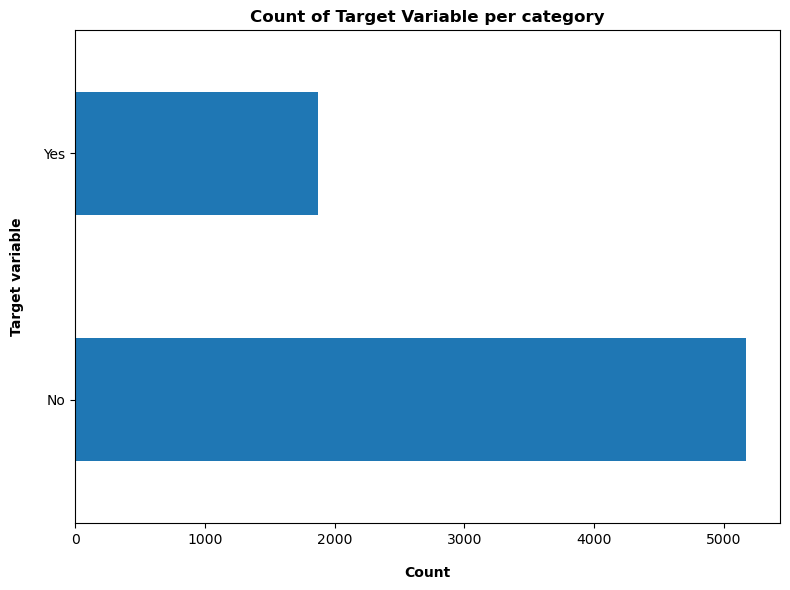

In [38]:
telco_churn['Churn'].value_counts().plot(kind='barh', figsize=(8,6))
plt.xlabel("Count", labelpad=14, fontweight='bold')
plt.ylabel("Target variable", labelpad=14, fontweight='bold')
plt.title("Count of Target Variable per category", fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
100*telco_churn['Churn'].value_counts()/len(telco_churn['Churn'])

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

In [40]:
telco_churn['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

-The imbalance can be clearly seen - 73:27 ratio

-Analysing the data further while taking the target variable separately can lead to some insights.

In [41]:
telco_churn.info(verbose=True)
#Using .info(verbose=True) to check missing values and dtypes immediately, also for a quick concise summary of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


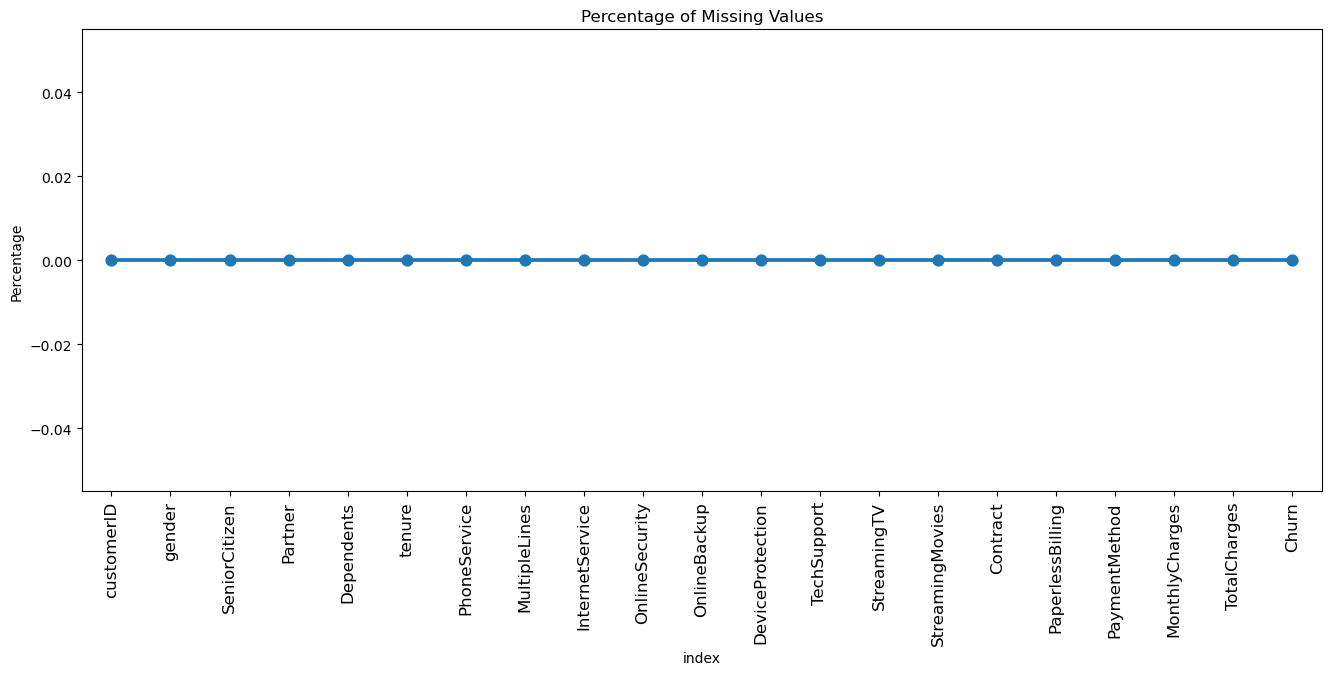

In [42]:
missing_values = pd.DataFrame((telco_churn.isnull().sum()) * 100/telco_churn.shape[0]).reset_index()
missing_values.columns = ['index','percentage']
plt.figure(figsize=(16,6))
ax=sns.pointplot(x='index',y='percentage',data=missing_values)
plt.xticks(rotation=90, fontsize=12)
plt.title("Percentage of Missing Values")
plt.ylabel('Percentage')
plt.show()

# Insights

A/C to the pointplot there is no missing data in the dataset

# Data Cleaning

Always create a copy of the original database for the following reasons:

- For comparison with the original dataset

- For code debugging if unexpected error occurs

- Re-running analysis with different approaches if required

In [43]:
data_df = telco_churn.copy()

The total charges column was seen to an object type while checking the dtypes. So, converting it to a numeric column.

In [44]:
data_df.TotalCharges = pd.to_numeric(data_df.TotalCharges, errors='coerce')
data_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

As seen there are 11 NaN values in the TotalCharges column. Checking what these records are.

In [45]:
data_df.loc[data_df['TotalCharges'].isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


As it is clear that the tenure for the total charges column having NaN values is 0, which suggests that these customers are new customers who do not generate total charges yet.

As the NaN columns are very low we can either drop them or convert them to zero. Here, it is more appropriate to convert them to zero as the business will make more sense out of zero tenure

The reason for filling them with 0 and not with forward filling or mean imputation is that they would distort for low tenure customers.

In [46]:
data_df['TotalCharges'] = data_df['TotalCharges'].fillna(0)

In [47]:
#Getting the max tenure 
print(data_df['tenure'].max())

72


In [49]:
data_df.to_csv("telco_clean_unique.csv", index=False)
print("data_df saved as 'telco_clean_unique.csv'") #Saving the clean dataset with customer ID for SQL processing and model building

data_df saved as 'telco_clean_unique.csv'


As customer ID is an unique identifier dropping it would make more sense as it won't add any predictive power and the model would just treat it as noise

Why not more? because dropping any other columns like the services, or payment methods would reduce the model accuracy because they strongly contribute to customer churn.

In [50]:
data_df.drop('customerID', axis=1, inplace=True)
print(data_df.columns.tolist())
print(data_df.shape)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
(7043, 20)


In [51]:
data_df.to_csv("telco_clean.csv", index=False)
print("data_df saved as 'telco_clean.csv'")

data_df saved as 'telco_clean.csv'


## EDA 

Checking the class balance first

In [52]:
print(data_df['Churn'].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


# 1. Univariate Analysis

To examine each feature alone. Starting with numeric columns first (tenure, MonthlyCharges, TotalCharges)

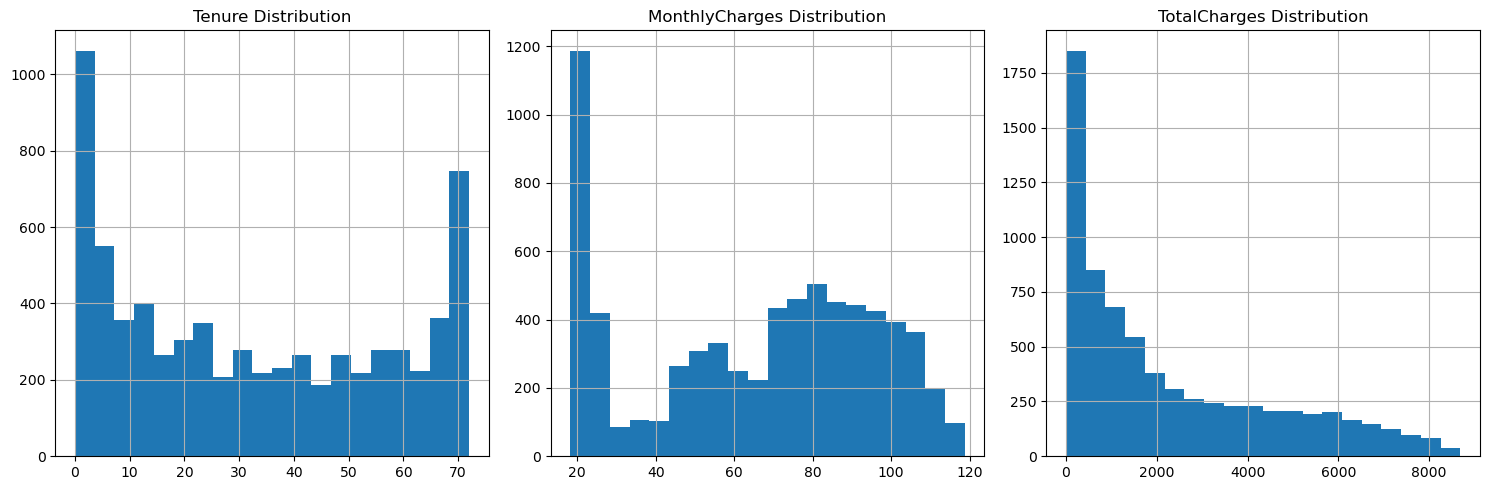

In [53]:
fig,axes = plt.subplots(1,3, figsize=(15,5))
data_df['tenure'].hist(ax=axes[0], bins=20)
axes[0].set_title('Tenure Distribution')

data_df['MonthlyCharges'].hist(ax=axes[1], bins=20)
axes[1].set_title('MonthlyCharges Distribution')

data_df['TotalCharges'].hist(ax=axes[2], bins=20)
axes[2].set_title('TotalCharges Distribution')

plt.tight_layout()
plt.show()

# Key inferences from the distribution

- Tenure: Distribution is U-shaped. There are many new customers ranging between 0-10 months wiht long-term customers ranging between 60-72 months. Hence, these is high churn risk at both ends
- MonthlyCharges: Distribution is right-skewed, peaking at $20-30. There is a low charge cluster as well maybe the basic plans.
- TotalCharges: Distribution is highly right-skewed, with many low totals suggesting new/short-term customers

Categorical Columns (top ones)

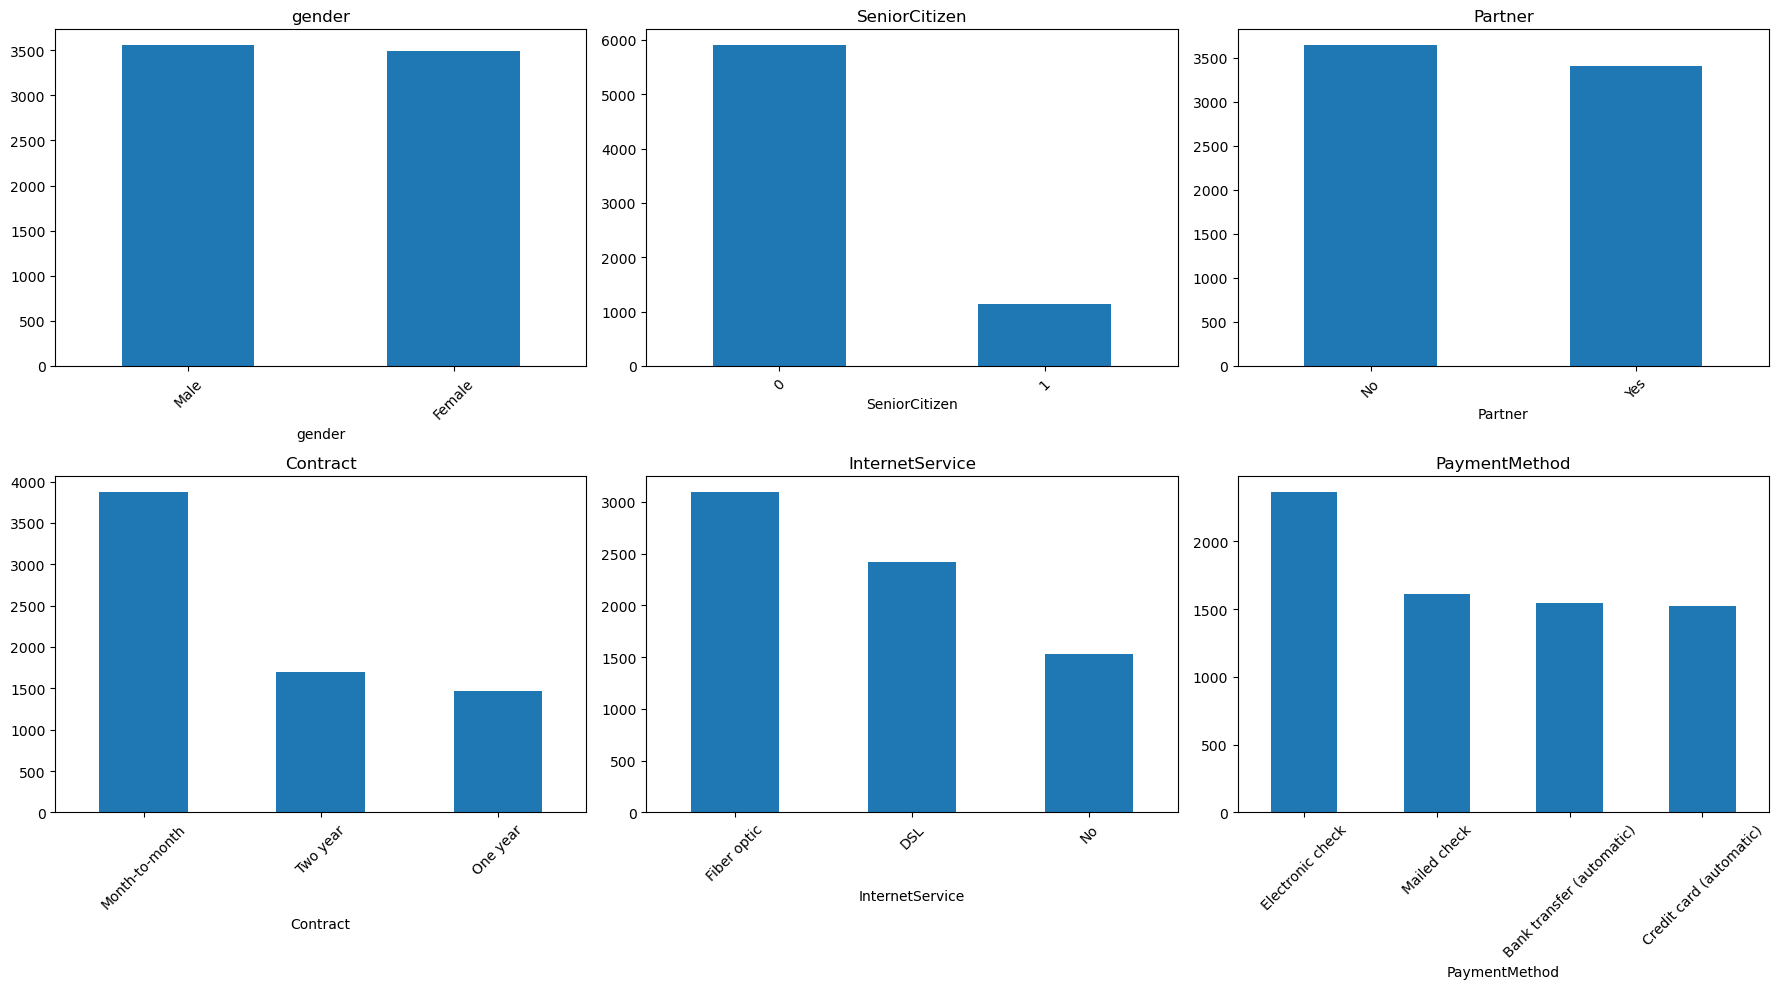

In [54]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(2, 3, figsize=(18,10))
for i, col in enumerate(cat_cols):
    row, col_idx = i//3, i%3
    data_df[col].value_counts().plot(kind='bar', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Key inference from the distribution

- Gender: Balanced(50/50). Unlikely for strong churn driver.
- SeniorCitizen: Imbalanced and rare. Can target senior citizen if they churn more.
- Partner: 43-50% aproxx. Family status may influence loyalty.
- Contract: Month-to-month is higher meaning short contracts are at higher churn rate.
- InternetService: Fiber/DSL has a higher value.
- PaymentMethd: It is clear that payment ease affects retention.

Target (Churn)

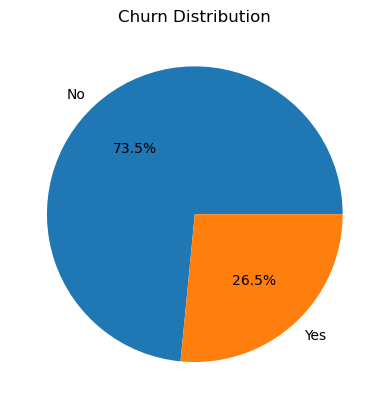

In [55]:
data_df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()

## Key inference: 
- severe class imbalance

  Impact: Standard accuracy metric useless (73% accuracy by predicting 'No' always)

# 2. Bivariate Analysis

Churn vs categoricals

In [56]:
priority_cats = ['Contract', 'InternetService', 'PaymentMethod']

for col in priority_cats:
    print(f"\nChurn rate by {col}:")
    print(data_df.groupby(col)['Churn'].value_counts(normalize=True).round(3))


Churn rate by Contract:
Contract        Churn
Month-to-month  No       0.573
                Yes      0.427
One year        No       0.887
                Yes      0.113
Two year        No       0.972
                Yes      0.028
Name: proportion, dtype: float64

Churn rate by InternetService:
InternetService  Churn
DSL              No       0.810
                 Yes      0.190
Fiber optic      No       0.581
                 Yes      0.419
No               No       0.926
                 Yes      0.074
Name: proportion, dtype: float64

Churn rate by PaymentMethod:
PaymentMethod              Churn
Bank transfer (automatic)  No       0.833
                           Yes      0.167
Credit card (automatic)    No       0.848
                           Yes      0.152
Electronic check           No       0.547
                           Yes      0.453
Mailed check               No       0.809
                           Yes      0.191
Name: proportion, dtype: float64


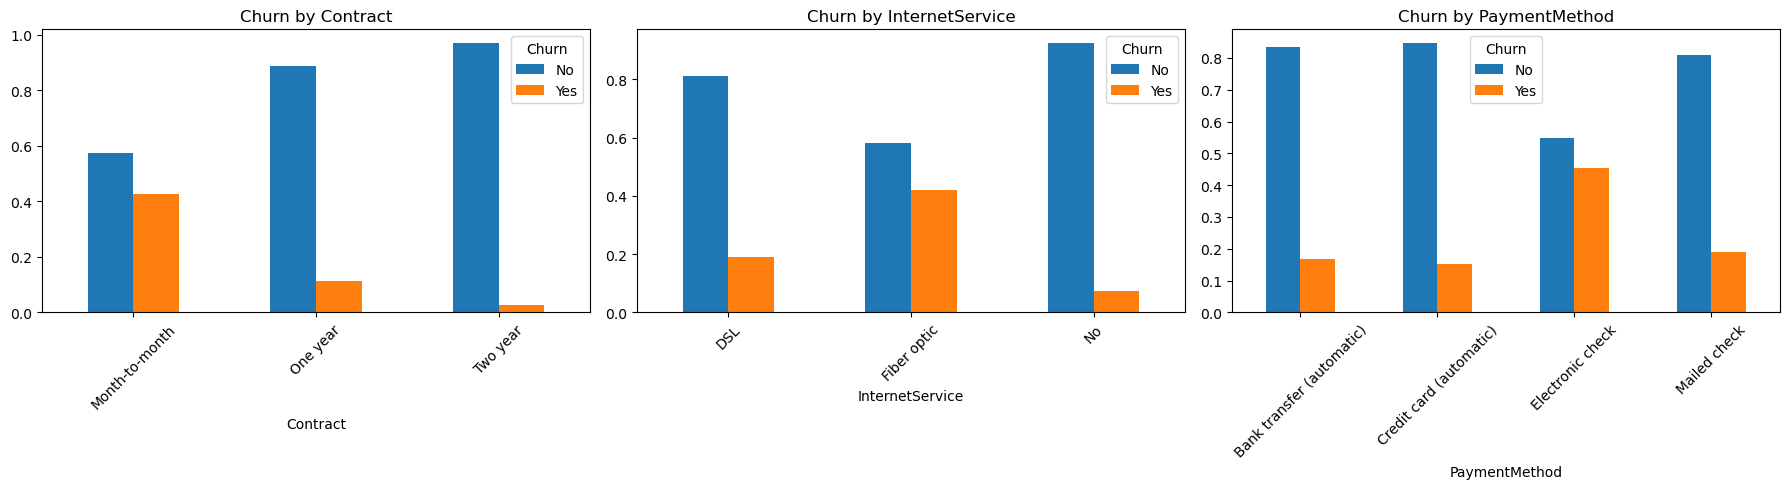

In [57]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(priority_cats):
    pd.crosstab(data_df[col], data_df['Churn'], normalize='index').plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Churn by {col}')
    axes[i].legend(title='Churn')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Top 3 inferenes: 
- Contract strongest driver: Month-to-month contract has almost 50% churnw whereas two year contract almost 3% churn. So, pushing longer contracts would be a better call.
- PaymentMentod matters: Electronic check highest churn (50%). Bank transfer/credit card lowest (15%). Simplyfy payments.
- InternetService: Fiber Optic higher churn than DSL. Premium service customers leave faster.

Actionable: Offer month-to-month customers contract upgrades + easy payment and bundle DSL for retention.

# 3. Correlation 
Numeric categories vs Churn

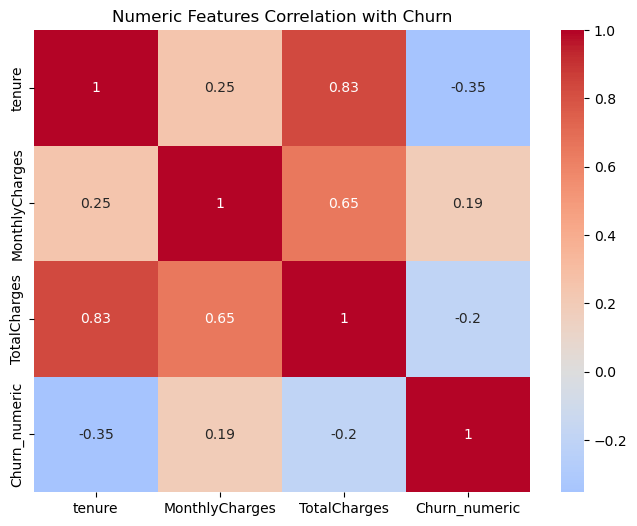

In [58]:
data_df['Churn_numeric'] = (data_df['Churn'] == 'Yes').astype(int)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']

corr_matrix = data_df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Numeric Features Correlation with Churn')
plt.show()

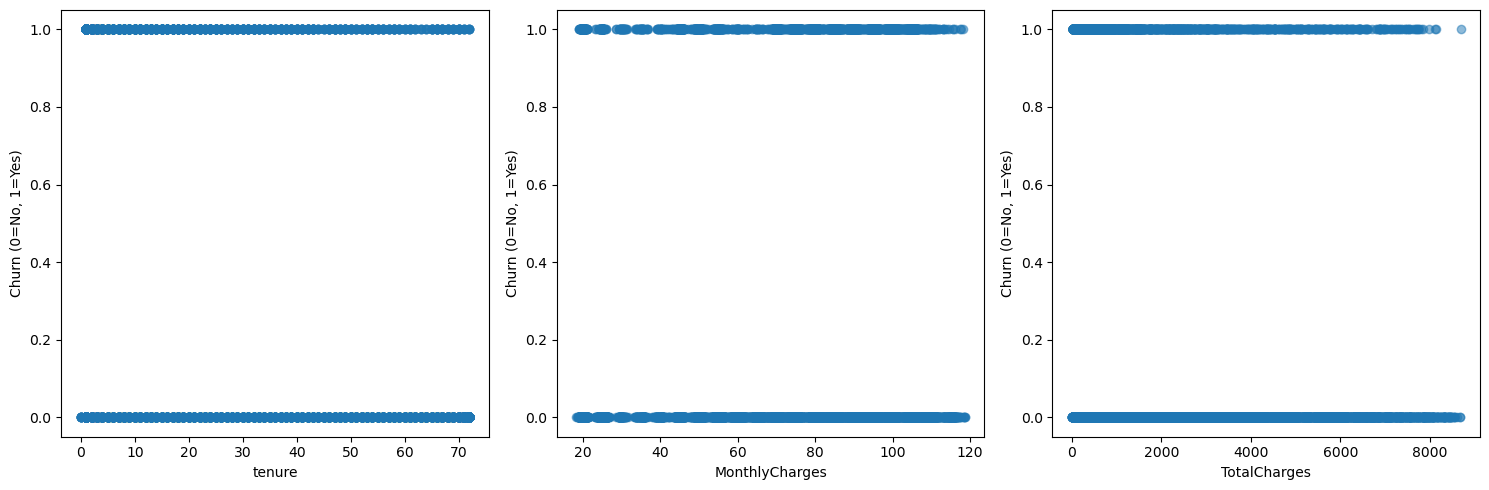

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    axes[i].scatter(data_df[col], data_df['Churn_numeric'], alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Churn (0=No, 1=Yes)')
plt.tight_layout()
plt.show()


# Key numeric inferences: 
Correlation matrix: 
- Tenure & TotalCharges: Strong positive (0.83). Longer customers accumulate charges.
- Churn strongest links:

  -Tenure: -0.35 (shorter tenure=higher churn)
  
  -TotalCharges: -0.20 (low total=higher churn)
  
  -MonthlyCharges: +19 (higher monthly = higher churn)

Scatterplots confirmation:
- Churn dots clusters at low tenure/low total charges
- Monthly charges has weak pattern

Business insights: Early tenure customers are more at risk. Highly monthly bills drive churn despite tenure.